# New-Gen Attention Family Analysis

This notebook analyzes blind attention-vs-MLP contrast metrics from `attention_detection` outputs.

Goals:
- visualize layer-wise signals across models
- check whether edited layers are local outliers
- compare raw vs local-window scores

In [ ]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({'figure.figsize': (16, 5), 'axes.grid': True, 'grid.alpha': 0.3})

ROOT = Path.cwd().resolve()
for p in [ROOT, *ROOT.parents]:
    if (p / 'notebooks' / 'new-gen' / '_newgen_utils.py').exists():
        ROOT = p
        break

sys.path.insert(0, str(ROOT / 'notebooks' / 'new-gen'))
from _newgen_utils import latest_structural_runs, select_run_files, load_json, flatten_metric_table, collect_detection_predictions

In [ ]:
model_filter = ['gpt2-large', 'gpt2-xl', 'qwen3-4b']
use_sweep_aware = True

selection = 'latest_model_sweep' if use_sweep_aware else 'latest_model'
all_run_files = latest_structural_runs(
    ROOT,
    max_files=500,
    model_substrings=model_filter,
    include_outputs=True,
    recursive=True,
)
run_files = select_run_files(all_run_files, selection=selection)
payloads = [load_json(p) for p in run_files]
print(f'Loaded {len(payloads)} run files (selection={selection})')
for p in run_files:
    print(' -', p.name)

Loaded 9 run files
 - rome_structural_qwen3-4b_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_12-44-06.json
 - rome_structural_qwen3-4b_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_12-27-58.json
 - rome_structural_gpt2-xl_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_12-17-45.json
 - rome_structural_gpt2-xl_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_12-07-43.json
 - rome_structural_gpt2-large_tk64_tf3_tl3_nl2_rw9_lw5-9-13_s02_r01_2026-03-24_12-02-59.json
 - rome_structural_gpt2-large_tk50_tf2_tl2_nl1_rw5_lw3-5-7_s01_r01_2026-03-24_11-58-12.json
 - rome_structural_gpt2-xl_2026-03-24_02-47-55.json
 - rome_structural_gpt2-large_2026-03-24_01-20-36.json
 - rome_structural_qwen3-4b_2026-03-23_18-09-51.json


In [ ]:
metric_paths = {
    'combined_score': ('combined_score',),
    'raw_rank_score': ('raw_rank_score',),
    'proj_attn_norm_log_ratio': ('contrast_series', 'proj_attn_norm_log_ratio'),
    'proj_attn_top1_gap': ('contrast_series', 'proj_attn_top1_gap'),
    'proj_attn_rank_gap': ('contrast_series', 'proj_attn_rank_gap'),
    'raw_local_max': ('local_window_scores', 'raw_rank', 'max_local_rank'),
}

frames = []
for payload in payloads:
    df = flatten_metric_table(payload, detection_key='attention', metric_paths=metric_paths)
    if not df.empty:
        frames.append(df)

attention_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
attention_df.head()

,source,case_id,model,layer,value,target_layer,metric
0,baseline,-1,Qwen/Qwen3-4B,0,0.812381,NaN,combined_score
1,baseline,-1,Qwen/Qwen3-4B,1,0.691905,NaN,combined_score
2,baseline,-1,Qwen/Qwen3-4B,2,0.617143,NaN,combined_score
3,baseline,-1,Qwen/Qwen3-4B,3,0.658095,NaN,combined_score
4,baseline,-1,Qwen/Qwen3-4B,4,0.533810,NaN,combined_score


In [ ]:
if attention_df.empty:
    print('No attention detection data found in selected runs.')
else:
    summary = (attention_df[attention_df['source'] == 'test']
               .groupby(['model', 'metric'])['value']
               .agg(['count', 'mean', 'std'])
               .reset_index())
    display(summary)

,model,metric,count,mean,std
0,Qwen/Qwen3-4B,combined_score,216,0.621358,0.086192
1,Qwen/Qwen3-4B,proj_attn_norm_log_ratio,216,0.697450,0.086516
2,Qwen/Qwen3-4B,proj_attn_rank_gap,216,898.051284,43.101739
3,Qwen/Qwen3-4B,proj_attn_top1_gap,216,0.007068,0.005369
4,Qwen/Qwen3-4B,raw_local_max,216,0.670899,0.248591
5,Qwen/Qwen3-4B,raw_rank_score,216,0.500000,0.094643
6,gpt2-large,combined_score,216,0.615088,0.074183
7,gpt2-large,proj_attn_norm_log_ratio,216,0.686392,0.154593
8,gpt2-large,proj_attn_rank_gap,216,255.097540,26.232622
9,gpt2-large,proj_attn_top1_gap,216,0.006307,0.004901


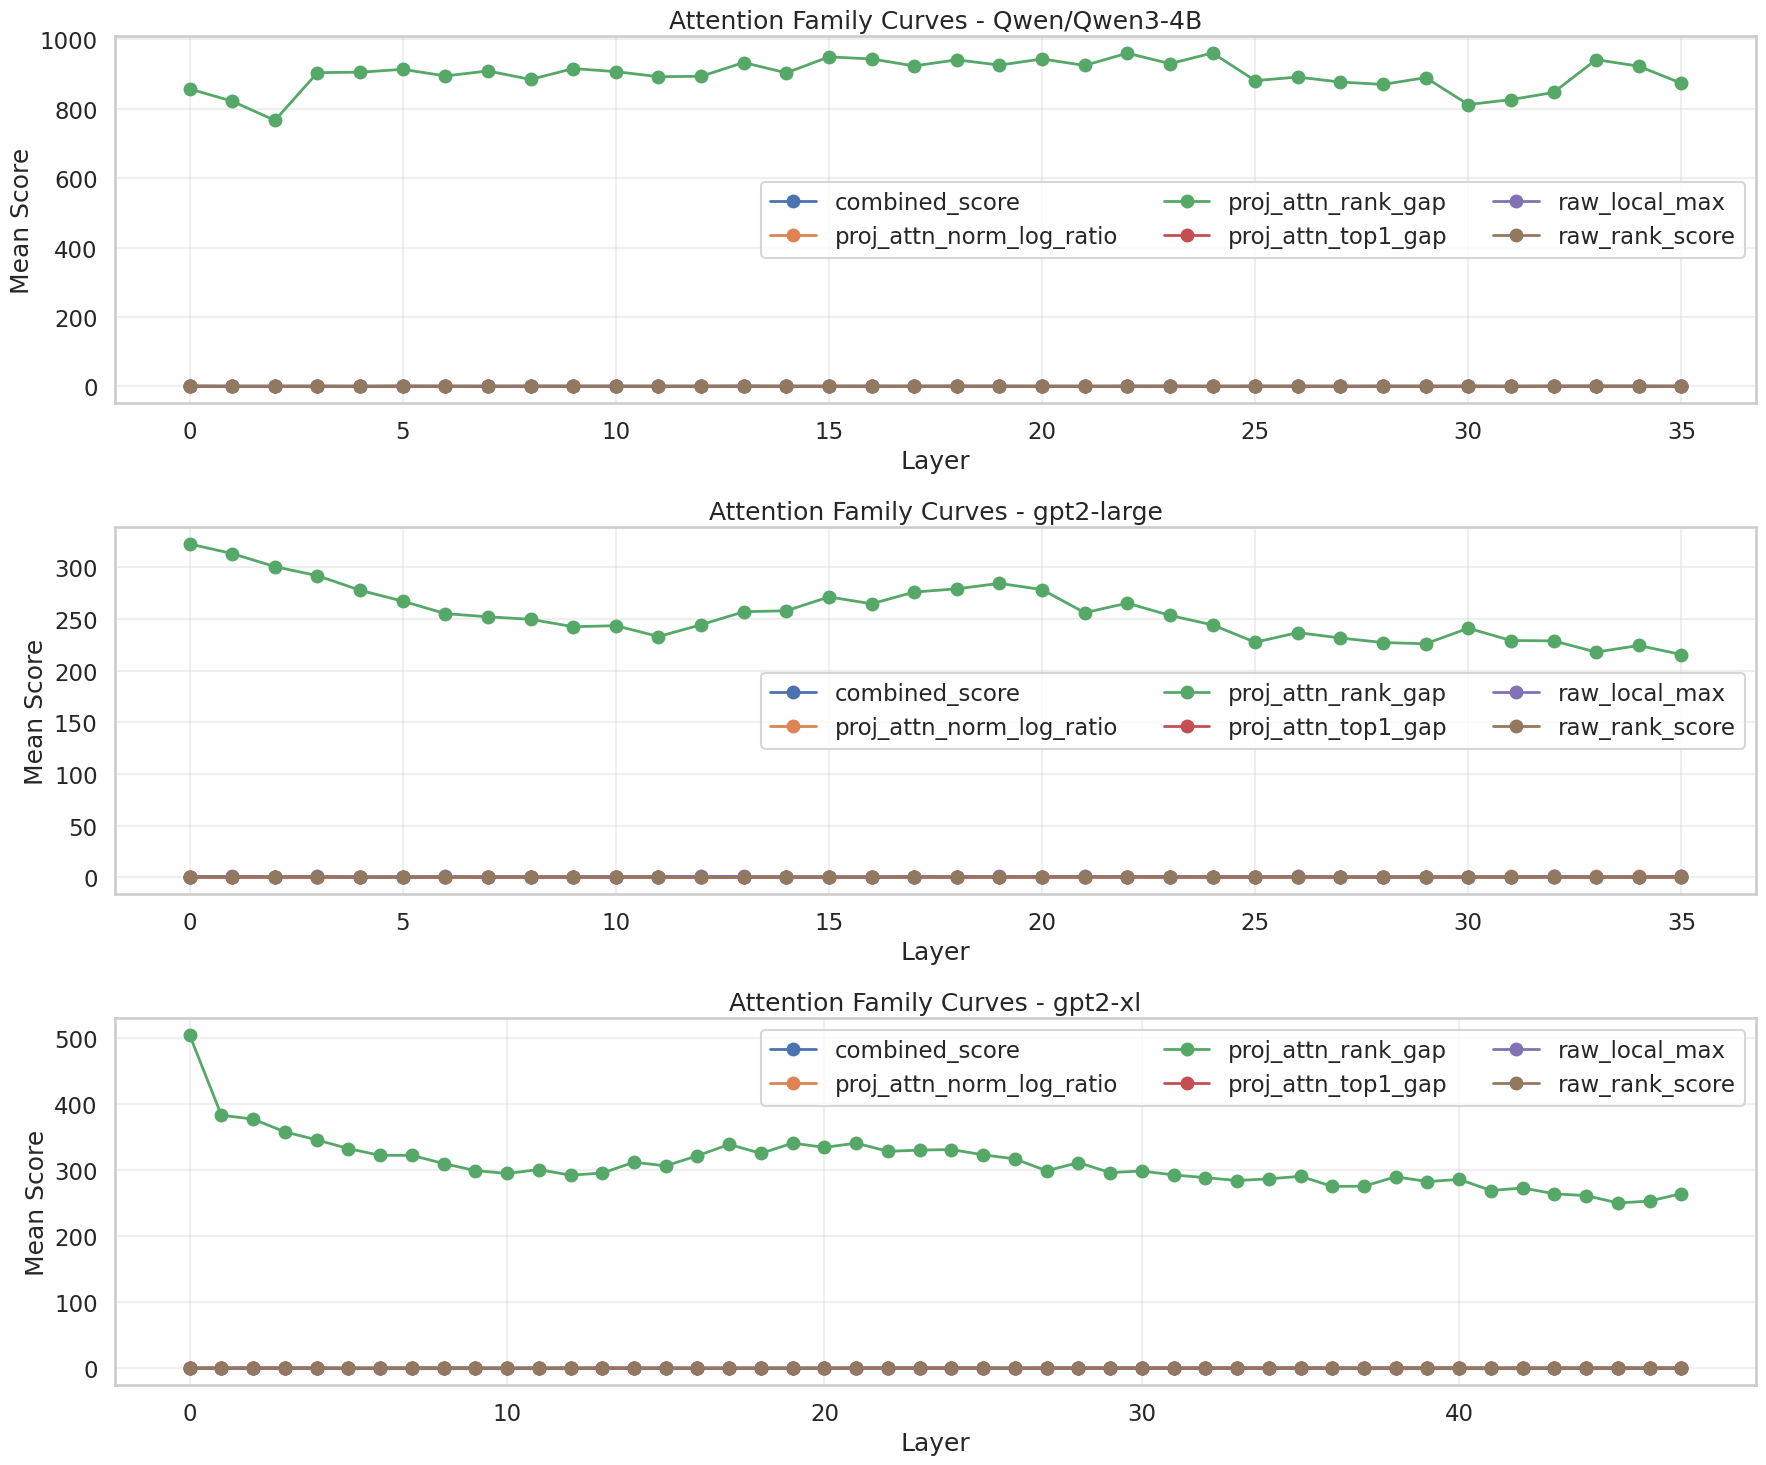

In [ ]:
if not attention_df.empty:
    test_df = attention_df[attention_df['source'] == 'test'].copy()
    agg = (test_df.groupby(['model', 'metric', 'layer'])['value']
           .mean()
           .reset_index())

    models = sorted(agg['model'].unique())
    metrics = sorted(agg['metric'].unique())
    fig, axes = plt.subplots(len(models), 1, figsize=(18, 5 * len(models)), sharex=False)
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        sub = agg[agg['model'] == model]
        for metric in metrics:
            line = sub[sub['metric'] == metric]
            if line.empty:
                continue
            ax.plot(line['layer'], line['value'], marker='o', linewidth=2, label=metric)
        ax.set_title(f'Attention Family Curves - {model}')
        ax.set_xlabel('Layer')
        ax.set_ylabel('Mean Score')
        ax.legend(loc='best', ncol=3)

    plt.tight_layout()
    plt.show()

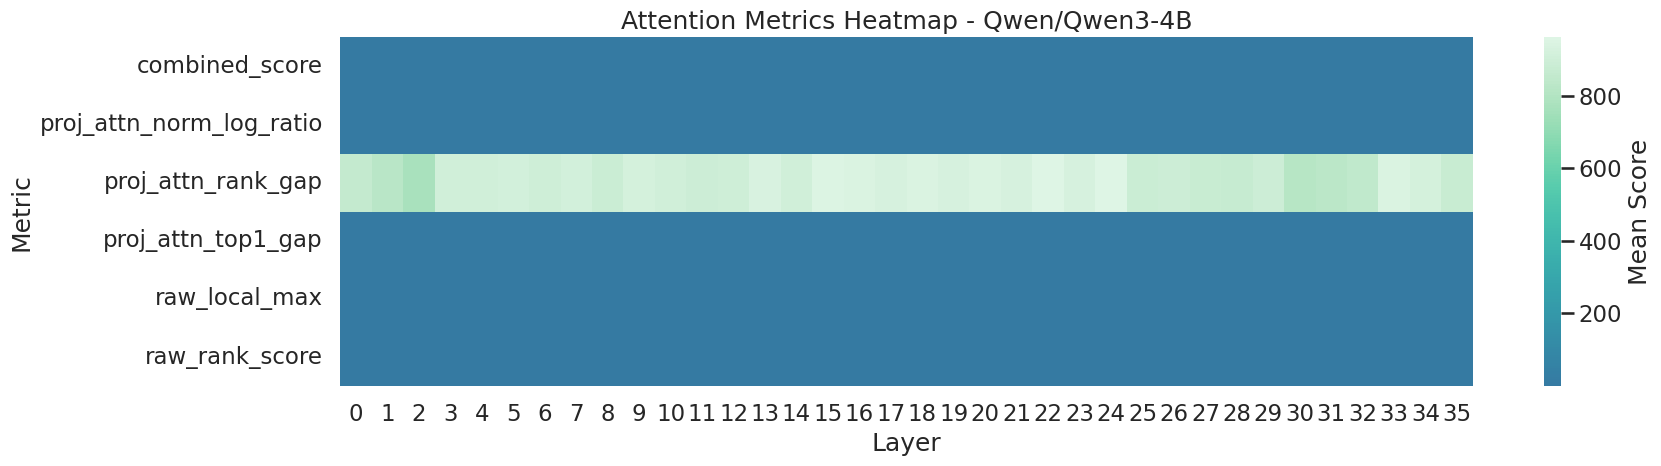

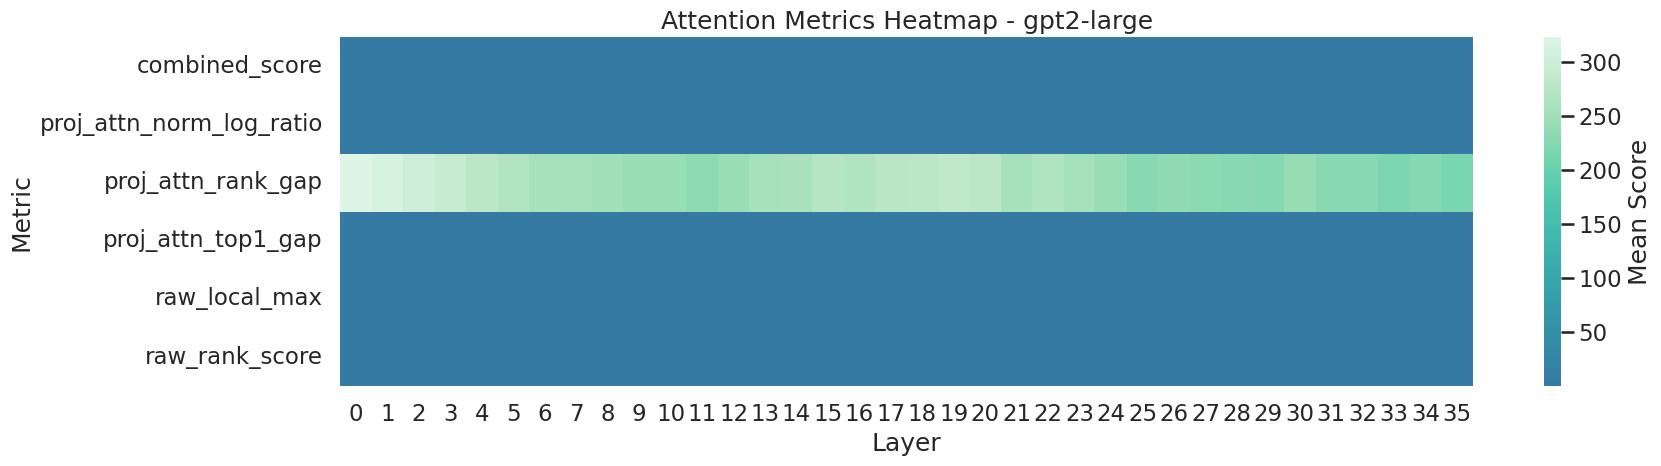

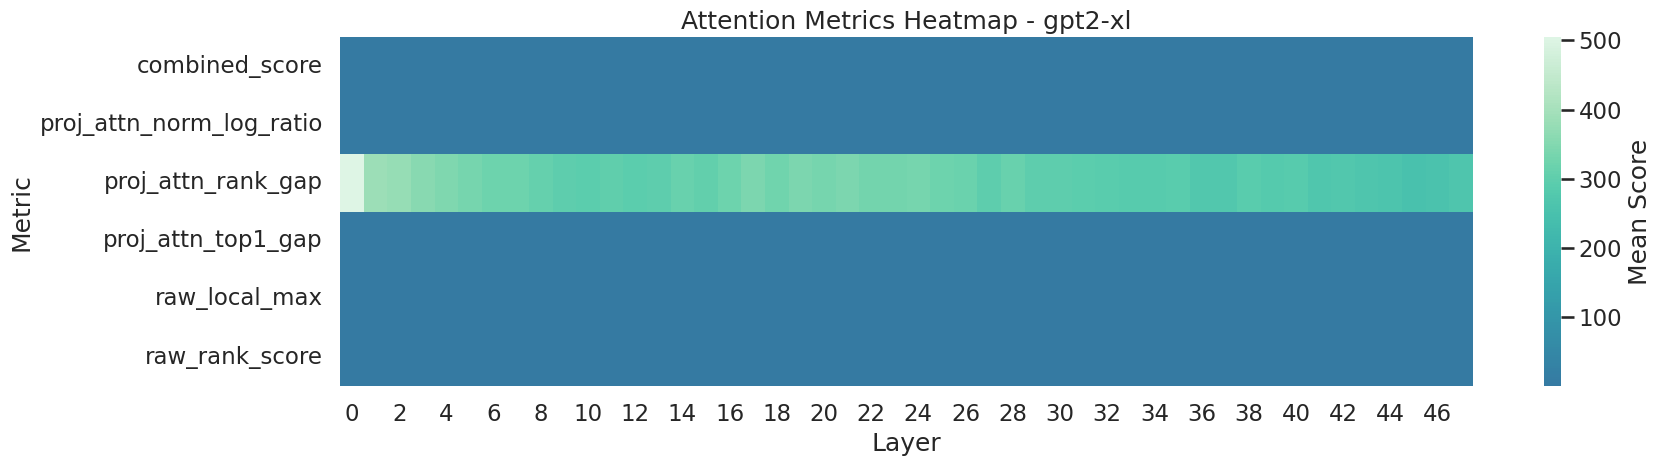

In [ ]:
if not attention_df.empty:
    test_df = attention_df[attention_df['source'] == 'test']
    for model in sorted(test_df['model'].unique()):
        pivot = (test_df[test_df['model'] == model]
                 .groupby(['metric', 'layer'])['value']
                 .mean()
                 .unstack(fill_value=np.nan))
        plt.figure(figsize=(18, 5))
        sns.heatmap(pivot, cmap='mako', center=np.nanmedian(pivot.values), cbar_kws={'label': 'Mean Score'})
        plt.title(f'Attention Metrics Heatmap - {model}')
        plt.xlabel('Layer')
        plt.ylabel('Metric')
        plt.tight_layout()
        plt.show()

In [ ]:
pred_frames = [collect_detection_predictions(p, detection_key='attention') for p in payloads]
pred_df = pd.concat(pred_frames, ignore_index=True) if pred_frames else pd.DataFrame()

if pred_df.empty:
    print('No prediction rows for attention detector.')
else:
    summary = pred_df.groupby('model').agg(
        n=('correct', 'size'),
        accuracy=('correct', 'mean'),
        mean_score=('detection_score', 'mean'),
    ).reset_index()
    display(summary)
    display(pred_df.head(20))

,model,n,accuracy,mean_score
0,Qwen/Qwen3-4B,106,0.0,0.819048
1,gpt2-large,106,0.0,0.729048
2,gpt2-xl,106,0.0,0.766489


,model,case_id,target_layer,predicted_layer,detection_score,correct
0,Qwen/Qwen3-4B,3,12,13,0.802857,False
1,Qwen/Qwen3-4B,4,12,13,0.791429,False
2,Qwen/Qwen3-4B,5,12,13,0.802857,False
3,Qwen/Qwen3-4B,0,12,13,0.839048,False
4,Qwen/Qwen3-4B,1,12,13,0.839048,False
5,Qwen/Qwen3-4B,2,12,13,0.839048,False
6,gpt2-xl,3,18,2,0.795035,False
7,gpt2-xl,4,18,2,0.795035,False
8,gpt2-xl,5,18,2,0.795035,False
9,gpt2-xl,0,18,38,0.737943,False
